In [1]:
import rasterio
import math
import numpy as np
import geopandas as gpd
import sys
import matplotlib.pyplot as plt

from rasterio.merge import merge
from rasterio.windows import from_bounds
from rasterio.io import MemoryFile # Lets you read / write files in RAM without having to touch disk
from rasterio.plot import plotting_extent

In [2]:
BBOX = (-105.27, 39.69, -105.17, 39.79)
 
YEAR = 2021          # 2020 or 2021
VERSION = "v200"      # "v100" for 2020, "v200" for 2021
OUTPUT_TIF = "../imports/worldcover_clip.tif"
 
BASE_URL = f"https://esa-worldcover.s3.amazonaws.com/{VERSION}/{YEAR}/map"

In [3]:
def tile_id(lat_ll, lon_ll):
    """
    This function returns the World Cover tile associated with a gicen coordinate location

    Paramters:
        lat_ll (float): The latitude coordinate
        lon_ll (float): The longitude coordinate
    
    Returns:
        str: The lookup string for the World Cover tile
    """
    ns = "N" if lat_ll >= 0 else "S"
    ew = "E" if lon_ll >= 0 else "W"

    return f"{ns}{abs(lat_ll):02d}{ew}{abs(lon_ll):03d}"
 
 
def tiles_for_bbox(west, south, east, north, step=3):
    """
    This function gathers all of the World Cover tiles within and touching the provided bounding box

    Paramters:
        west, south, east, north (float): The four coordinates describing the bounding box
    
    Returns:
        list[str]: A list of the world cover tile ids within the provided bounding box
    """
    lat_start = math.floor(south / step) * step
    lat_end = math.floor(north / step) * step
    lon_start = math.floor(west / step) * step
    lon_end = math.floor(east / step) * step
 
    ids = []
    lat = lat_start
    while lat <= lat_end:
        lon = lon_start
        while lon <= lon_end:
            ids.append(tile_id(lat, lon))
            lon += step
        lat += step

    return ids

In [4]:
def get_tile_data(urls):
    """
    This function retrieves all of the world cover tiles associated with the URL links in the given parameter

    Parameters:
        urls (list[str]): A list of AWS bucket links associated with world cover tiles
    
    Returns:
        list[tuple]: A dictionary containing the raster data from each of the world cover tiles. 
    """
    clips = []
    for url in urls:
        # Open a URL stream with rasterio
        # does not require making an API request 
        with rasterio.open(url) as src:
            window = from_bounds(*BBOX, transform=src.transform)
            window = window.round_offsets().round_lengths()

            # skip tiles that don't actually intersect (can happen at edges)
            if window.width <= 0 or window.height <= 0:
                continue

            # Retrieve the necessary data and transform info from the file
            transform = src.window_transform(window)
            data = src.read(1, window=window)
            clips.append((data, transform, src.crs))
    
    if not clips:
        raise SystemExit("No data found for this bbox — check coordinates/order (west, south, east, north).")

    return clips

In [5]:
def merge_and_save_tiles(clips):
    """
    This function merges each of the individual world cover tiles together from clips and exports them locally to a .tif file

    Parameters:
        clips (list[tuple]): A list containing the data and transform information from World cover tiles
    """
    if len(clips) == 1:
        data, transform, crs = clips[0]
        data = data[np.newaxis, :, :]

    else:
        # merge() wants rasterio dataset-like objects; easiest is to write
        # each clip to an in-memory dataset first
        memfiles = []
        for arr, transform, crs in clips:
            # Create a memoryfile from the clip
            mem = MemoryFile()
            with mem.open(
                driver="GTiff", height=arr.shape[0], width=arr.shape[1],
                count=1, dtype=arr.dtype, crs=crs, transform=transform,
            ) as dst:
                dst.write(arr, 1)

            memfiles.append(mem)

        data, transform = merge([mf.open() for mf in memfiles]) # combines multiple adjacent / overlapping raster datasets into one
        crs = clips[0][2]

    # Export the merged file locally 
        # Export the merged file locally 
    with rasterio.open(
        OUTPUT_TIF, "w", driver="GTiff",
        height=data.shape[-2], width=data.shape[-1],
        count=1, dtype=data.dtype, crs=crs, transform=transform,
    ) as dst:
        dst.write(data)  # data is already (bands, height, width) — no index needed
    
    print(f"Saved clipped raster to {OUTPUT_TIF}")

In [6]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

WORLDCOVER_CLASSES = {
    10:  ("Tree cover",               "#006400"),
    20:  ("Shrubland",                "#ffbb22"),
    30:  ("Grassland",                "#ffff4c"),
    40:  ("Cropland",                 "#f096ff"),
    50:  ("Built-up",                 "#fa0000"),
    60:  ("Bare / sparse vegetation", "#b4b4b4"),
    70:  ("Snow and ice",             "#f0f0f0"),
    80:  ("Permanent water bodies",   "#0064c8"),
    90:  ("Herbaceous wetland",       "#0096a0"),
    95:  ("Mangroves",                "#00cf75"),
    100: ("Moss and lichen",          "#fae6a0"),
}

def plot_shapes(idx, gdf, clips):
    arr, transform = clips[idx]
    fig, ax = plt.subplots(figsize=(8, 8))
    extent = plotting_extent(arr, transform)

    # Pull out only the valid (unmasked) pixel values before finding
    # unique classes — masked arrays otherwise return an unhashable
    # MaskedConstant placeholder for the masked-out pixels
    if np.ma.isMaskedArray(arr):
        valid_values = arr.compressed()
    else:
        valid_values = arr.ravel()

    present_classes = sorted(int(c) for c in np.unique(valid_values) if c in WORLDCOVER_CLASSES)

    colors = [WORLDCOVER_CLASSES[c][1] for c in present_classes]
    cmap = ListedColormap(colors)
    cmap.set_bad(alpha=0)  # render masked/nodata pixels as transparent

    boundaries = present_classes + [present_classes[-1] + 1]
    norm = BoundaryNorm(boundaries, cmap.N)

    im = ax.imshow(
        arr,
        extent=extent,
        cmap=cmap,
        norm=norm,
        interpolation="none",
    )

    gdf.loc[[idx]].boundary.plot(ax=ax, color="black", linewidth=1.5)
    ax.set_title(f"Shape {idx}")

    legend_handles = [
        mpatches.Patch(color=WORLDCOVER_CLASSES[c][1], label=WORLDCOVER_CLASSES[c][0])
        for c in present_classes
    ]
    ax.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        title="Land cover class",
    )

    plt.tight_layout()
    plt.show()

In [7]:
def cross_validate_greenspace(gdf, clips):
    """
    Go through each of the geometries in clips and cross validate that a majority of their space is indeed green space

    Parameters:
        clips (list[tuple]): A list containing the data and transform information from World cover tiles
        gdf (GeoDataframe): The dataframe including the green space geometries
    """
    GREEN_CLASSES = [10, 20, 30, 90, 95]

    non_green = []
    for idx, (arr, transform) in clips.items():
        arr = arr.compressed()

        green_mask = np.isin(arr, GREEN_CLASSES)
        pct_green = 100 * green_mask.sum() / green_mask.size

        if pct_green <= 20:
            # print(f"Not sufficient greenspace: {idx} {pct_green} covered")
            # amenity = gdf.loc[idx, 'amenity']
            # print(f"Amenity: {amenity}")
            non_green.append(idx)

    return  non_green

In [8]:
tile_ids = tiles_for_bbox(*BBOX)
urls = [f"{BASE_URL}/ESA_WorldCover_10m_{YEAR}_{VERSION}_{t}_Map.tif" for t in tile_ids]

clips = get_tile_data(urls)

merge_and_save_tiles(clips)

Saved clipped raster to ../imports/worldcover_clip.tif


In [9]:
raster_src = rasterio.open(OUTPUT_TIF)
arr = raster_src.read(1)

In [10]:
CLASS_CODES = {
    10: "Tree cover", 20: "Shrubland", 30: "Grassland", 40: "Cropland",
    50: "Built-up", 60: "Bare / sparse vegetation", 70: "Snow and ice",
    80: "Permanent water bodies", 90: "Herbaceous wetland",
    95: "Mangroves", 100: "Moss and lichen",
}

In [ ]:
sys.path.append('../scripts/') 
from elevation_categorization import clip_raster_to_shapes

gdf = gpd.read_file("../exports/ghe_locations.geojson")
# Make sure GeoJSON uses the same CRS as the raster
if gdf.crs != raster_src.crs:
    gdf = gdf.to_crs(raster_src.crs)

gdf, clips = clip_raster_to_shapes(raster_src, gdf)

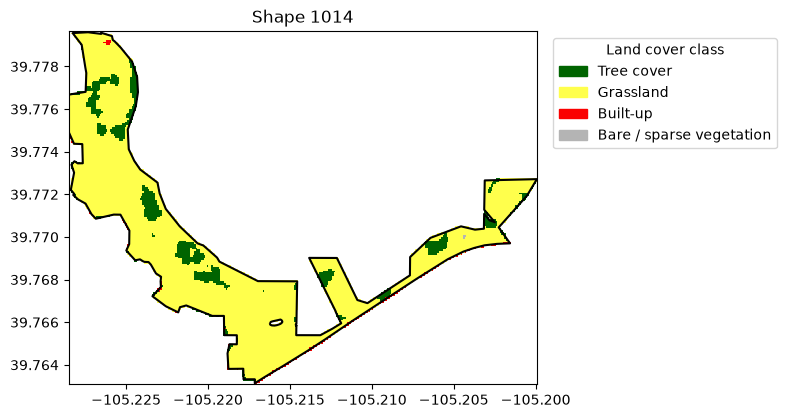

In [12]:
plot_shapes(1014, gdf, clips)

In [13]:
non_green = cross_validate_greenspace(gdf, clips)

In [14]:
filtered = gdf.loc[
    gdf.index.isin(non_green) &
    (gdf['amenity'] != 'parking')
]
filtered.explore()